# Exploring the KITTI object-detection dataset

A short look at what the data actually contains before any modelling:
what the sensors see, how the labels are distributed, and the properties
that later shaped the design decisions in `assignment.ipynb`. The full
preprocessing pipeline lives there; this notebook only visualises.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

LABEL_DIR = Path("./training/label_2")
CALIB_DIR = Path("./data_object_calib/training/calib")
IMAGE_DIR = Path("./data_object_image_2/training/image_2")
VELODYNE_DIR = Path("./training/velodyne")

COLOURS = {"Car": "#4da3ff", "Van": "#4dd2ff", "Truck": "#4dffea",
           "Pedestrian": "#ff5c5c", "Person_sitting": "#ff8c42",
           "Cyclist": "#ffd23f", "Tram": "#c084fc", "Misc": "#9ca3af",
           "DontCare": "#666666"}

COLUMNS = ["type", "truncated", "occluded", "alpha",
           "bbox_left", "bbox_top", "bbox_right", "bbox_bottom",
           "dim_height", "dim_width", "dim_length",
           "loc_x", "loc_y", "loc_z", "rotation_y"]

# One label file per frame, one object per line.
frames = []
for path in sorted(LABEL_DIR.glob("*.txt")):
    df = pd.read_csv(path, sep=r"\s+", header=None, names=COLUMNS,
                     engine="python")
    df.insert(0, "frame_id", path.stem)
    frames.append(df)
labels = pd.concat(frames, ignore_index=True)

print(f"{labels['frame_id'].nunique()} frames, {len(labels)} labelled objects")


7481 frames, 51865 labelled objects


In [2]:
# Figures are exported for slides: text must survive projection, so the base
# font is larger than the matplotlib default and figure width matches the width
# the figure will occupy on the slide (points are then literal, not rescaled).
FIGURE_DIR = Path("./figures")
FIGURE_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.facecolor": "white",
})


def save_figure(name):
    """Write the current figure to ./figures/<name>.png for the slide deck."""
    plt.savefig(FIGURE_DIR / f"{name}.png")


## What is labelled, and how much of it

Eight object classes plus `DontCare` (regions the annotators skipped, mostly
because they were too far for the laser). The dataset is heavily car-centred:
the class we care most about, pedestrians, is outnumbered more than 6:1.


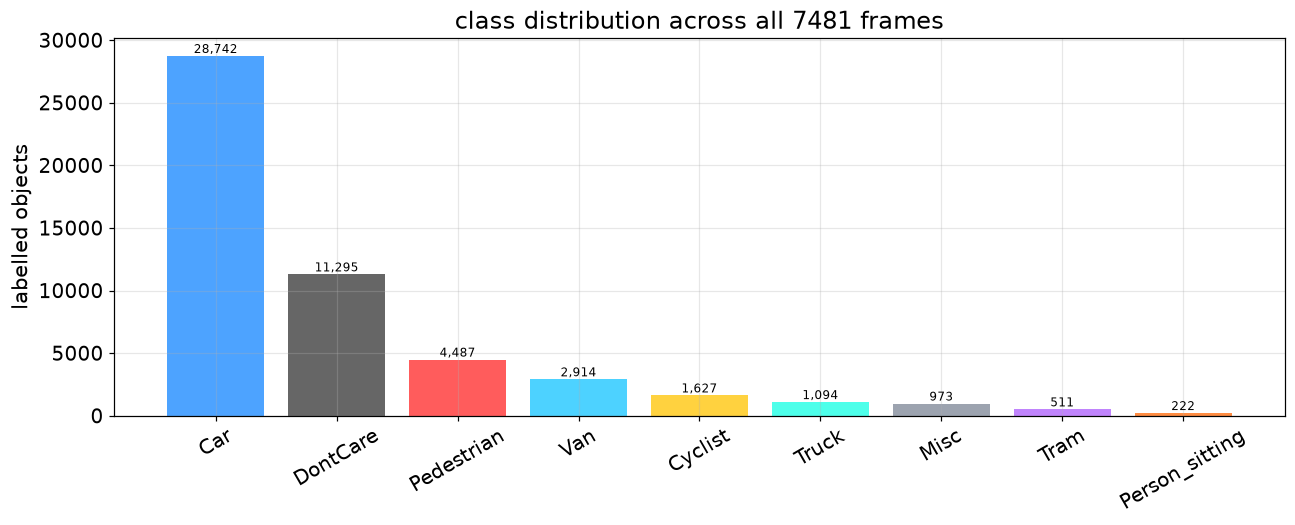

car : pedestrian ratio = 6.4 : 1


In [3]:
counts = labels["type"].value_counts()

plt.figure(figsize=(12, 5))
plt.bar(counts.index, counts.values,
        color=[COLOURS[c] for c in counts.index])
plt.ylabel("labelled objects")
plt.title("class distribution across all 7481 frames")
plt.xticks(rotation=30)
for i, value in enumerate(counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
save_figure("02_class_distribution")
plt.show()

print(f"car : pedestrian ratio = "
      f"{counts['Car'] / counts['Pedestrian']:.1f} : 1")


## What a frame looks like

Ground-truth boxes drawn straight from the label files. The boxes hug the
objects tightly, which is the visual confirmation that the parsing (column order,
pixel convention, frame-to-file mapping) is correct.


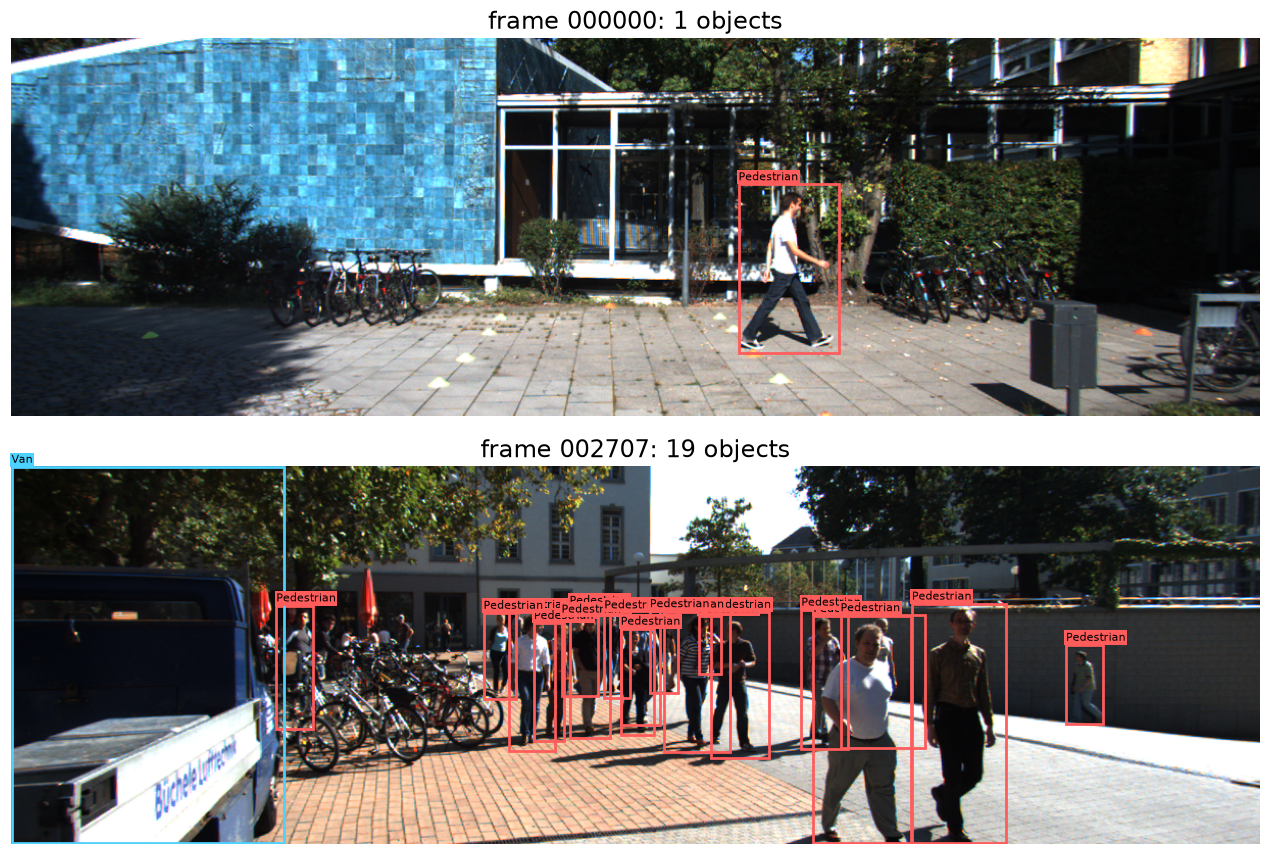

In [4]:
def show_frame(frame_id, ax):
    image = Image.open(IMAGE_DIR / f"{frame_id}.png").convert("RGB")
    ax.imshow(image)

    rows = labels[(labels["frame_id"] == frame_id)
                  & (labels["type"] != "DontCare")]
    for row in rows.itertuples():
        colour = COLOURS[row.type]
        ax.add_patch(patches.Rectangle(
            (row.bbox_left, row.bbox_top),
            row.bbox_right - row.bbox_left, row.bbox_bottom - row.bbox_top,
            linewidth=1.8, edgecolor=colour, facecolor="none"))
        ax.text(row.bbox_left, row.bbox_top - 4, row.type, color="black",
                fontsize=7, bbox=dict(facecolor=colour, edgecolor="none", pad=1))
    ax.set_title(f"frame {frame_id}: {len(rows)} objects")
    ax.axis("off")


# A quiet frame and the busiest pedestrian frame in the dataset.
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
show_frame("000000", axes[0])
show_frame("002707", axes[1])
plt.tight_layout()
plt.show()


## Where the objects are

Distance and apparent size decide how hard detection is. Pedestrians cluster
within ~30 m (beyond that the annotators increasingly marked `DontCare`),
and their on-image height shrinks with distance: a pedestrian at 40 m is
only a dozen pixels wide, which is what makes far detection hard for any
grid-based detector.


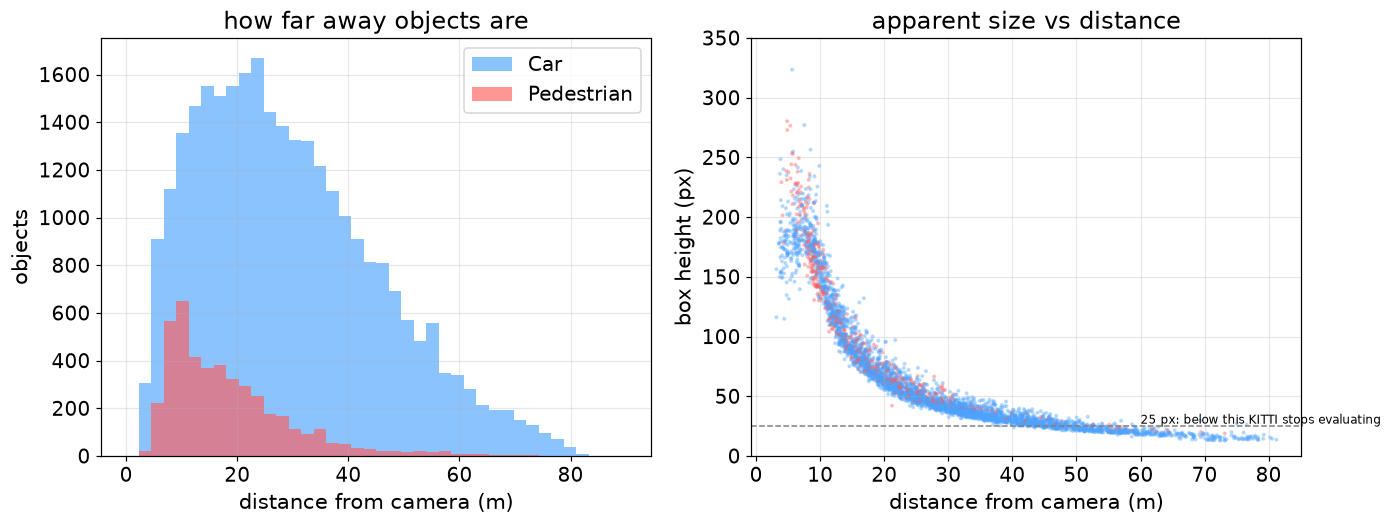

In [5]:
objects = labels[labels["type"].isin(["Car", "Pedestrian"])].copy()
objects["distance"] = np.sqrt(objects["loc_x"] ** 2
                              + objects["loc_y"] ** 2
                              + objects["loc_z"] ** 2)
objects["bbox_height"] = objects["bbox_bottom"] - objects["bbox_top"]

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 5))

# Distance distribution per class.
for class_name in ["Car", "Pedestrian"]:
    subset = objects[objects["type"] == class_name]
    left.hist(subset["distance"], bins=40, range=(0, 90), alpha=0.65,
              color=COLOURS[class_name], label=class_name)
left.set_xlabel("distance from camera (m)")
left.set_ylabel("objects")
left.set_title("how far away objects are")
left.legend()

# Apparent size shrinks with distance.
sample = objects.sample(4000, random_state=0)
right.scatter(sample["distance"], sample["bbox_height"], s=3, alpha=0.3,
              c=[COLOURS[t] for t in sample["type"]])
right.axhline(25, color="gray", linestyle="--", linewidth=1)
right.text(60, 27, "25 px: below this KITTI stops evaluating", fontsize=8)
right.set_xlabel("distance from camera (m)")
right.set_ylabel("box height (px)")
right.set_title("apparent size vs distance")
right.set_ylim(0, 350)

plt.tight_layout()
save_figure("03_size_vs_distance")
plt.show()


## Occlusion and truncation

Real street scenes are cluttered: a third of pedestrians are at least partly
hidden behind something, and objects at the image border are cut off. These
two fields, together with box height, define KITTI's easy/moderate/hard
difficulty tiers.


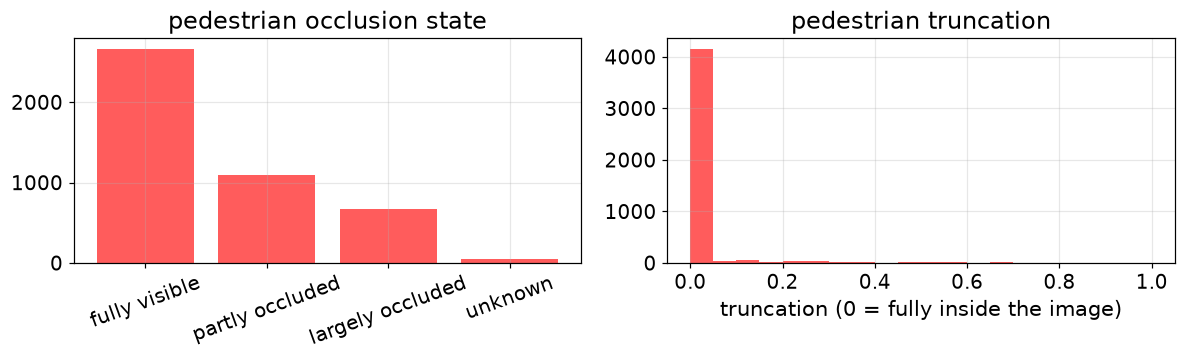

41% of pedestrians are at least partly occluded


In [6]:
pedestrians = labels[labels["type"] == "Pedestrian"]

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.5))

occlusion_labels = {0: "fully visible", 1: "partly occluded",
                    2: "largely occluded", 3: "unknown"}
occlusion = pedestrians["occluded"].value_counts().sort_index()
left.bar([occlusion_labels[i] for i in occlusion.index], occlusion.values,
         color=COLOURS["Pedestrian"])
left.set_title("pedestrian occlusion state")
left.tick_params(axis="x", rotation=20)

right.hist(pedestrians["truncated"], bins=20, color=COLOURS["Pedestrian"])
right.set_xlabel("truncation (0 = fully inside the image)")
right.set_title("pedestrian truncation")

plt.tight_layout()
plt.show()

visible = (pedestrians["occluded"] == 0).mean()
print(f"{100 * (1 - visible):.0f}% of pedestrians are at least partly occluded")


## The second modality: LiDAR

Each frame also carries a Velodyne scan: ~120k points of `x, y, z,
reflectance`. Projected into the image with the calibration matrices, the
points land exactly on the objects, and unlike pixels, each point knows its
distance in metres. This is the information the camera alone fundamentally
lacks, and fusing the two is the subject of `assignment.ipynb`.


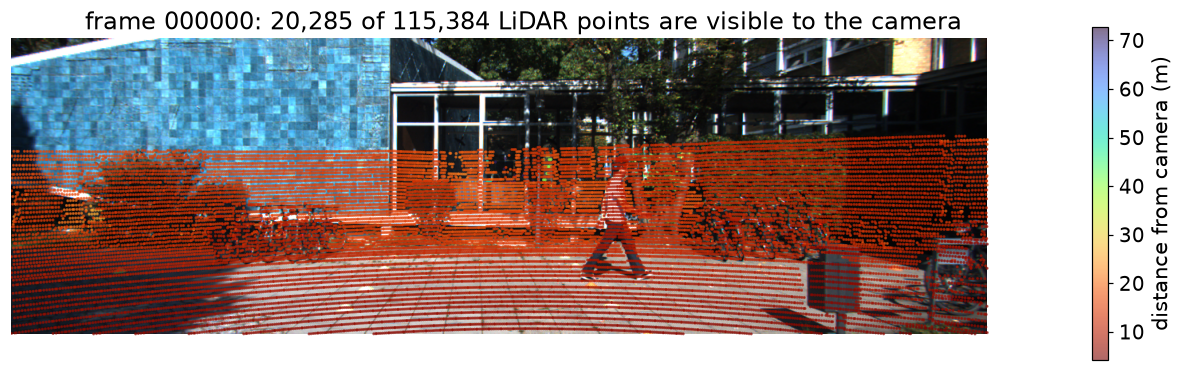

47% of the 360-degree scan points are behind the camera and never visible in the image


In [7]:
CALIB_SHAPES = {"P2": (3, 4), "R0_rect": (3, 3), "Tr_velo_to_cam": (3, 4)}


def read_calib(frame_id):
    """The three matrices needed for projection, padded to 4x4."""
    mats = {}
    for line in open(CALIB_DIR / f"{frame_id}.txt"):
        if ":" not in line:
            continue
        key, values = line.split(":", 1)
        key = key.strip()
        if key in CALIB_SHAPES:
            mat = np.array(values.split(), dtype=np.float64)
            mat = mat.reshape(CALIB_SHAPES[key])
            padded = np.eye(4)
            padded[:mat.shape[0], :mat.shape[1]] = mat
            mats[key] = padded
    return mats


frame_id = "000000"
calib = read_calib(frame_id)
image = Image.open(IMAGE_DIR / f"{frame_id}.png").convert("RGB")

points = np.fromfile(VELODYNE_DIR / f"{frame_id}.bin",
                     dtype=np.float32).reshape(-1, 4)

# Velodyne -> rectified camera coordinates (homogeneous form).
homogeneous = np.hstack([points[:, :3], np.ones((len(points), 1))])
camera = homogeneous @ calib["Tr_velo_to_cam"].T @ calib["R0_rect"].T

# Keep points in front of the camera, project, keep those on the image.
in_front = camera[:, 2] > 0
camera = camera[in_front]
projected = camera @ calib["P2"].T
pixels = projected[:, :2] / projected[:, 2:3]
depths = camera[:, 2]

width, height = image.size
inside = ((pixels[:, 0] >= 0) & (pixels[:, 0] < width)
          & (pixels[:, 1] >= 0) & (pixels[:, 1] < height))

fig, ax = plt.subplots(figsize=(13, 13 * height / width))
ax.imshow(image)
scatter = ax.scatter(pixels[inside, 0], pixels[inside, 1],
                     c=depths[inside], s=1, cmap="turbo_r", alpha=0.6)
plt.colorbar(scatter, ax=ax, fraction=0.025,
             label="distance from camera (m)")
ax.set_title(f"frame {frame_id}: {int(inside.sum()):,} of {len(points):,} "
             f"LiDAR points are visible to the camera")
ax.axis("off")
save_figure("01_lidar_overlay")
plt.show()

print(f"{100 * (~in_front).mean():.0f}% of the 360-degree scan points are "
      f"behind the camera and never visible in the image")


## Takeaways that shaped the pipeline

* **Severe class imbalance** (6.4 cars per pedestrian) -> the loss must not
  let the majority drown the minority.
* **Pedestrians are small and often occluded** -> detection difficulty tiers
  matter, and far objects are hard at any grid resolution.
* **Frames come from continuous drives** (consecutive frames are nearly identical)
  -> the train/validation split must be by drive, not by frame.
* **Half of every LiDAR scan is behind the camera** -> points must be
  filtered by depth sign before projection or they mirror into the image.
* **LiDAR knows distance, the camera knows appearance** -> the two are
  complementary, which is the case for sensor fusion.
